In [1]:
# Import library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from traffic.core import Traffic

import os
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split


---
# Anormaly Flights

In [2]:
anormal_df = pd.read_csv('df_anormaly_flights.csv')
anormal_df

,time,icao24,lat,lon,velocity,heading,vertrate,callsign,onground,alert,spi,squawk,baroaltitude,geoaltitude,lastposupdate,lastcontact,hour
0,1479505464,a42329,33.846736,-84.441147,196.046367,178.797116,0.32512,OPT366,False,False,False,3436.0,13716.00,14196.06,1.479505e+09,1.479505e+09,1.479503e+09
1,1479505465,a42329,33.846736,-84.441147,196.046367,178.797116,0.32512,OPT366,False,False,False,3436.0,13716.00,14196.06,1.479505e+09,1.479505e+09,1.479503e+09
2,1479505466,a42329,33.846736,-84.441147,196.046367,178.797116,0.32512,OPT366,False,False,False,3436.0,13716.00,14196.06,1.479505e+09,1.479505e+09,1.479503e+09
3,1479505467,a42329,33.841965,-84.441030,196.046367,178.797116,0.32512,OPT366,False,False,False,3436.0,13716.00,14196.06,1.479505e+09,1.479505e+09,1.479503e+09
4,1479505468,a42329,33.839799,-84.440975,196.046367,178.797116,0.32512,OPT366,False,False,False,3436.0,13716.00,14196.06,1.479505e+09,1.479505e+09,1.479503e+09
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6356,1584900480,a95243,33.842972,-84.435425,187.560526,332.029200,-8.45312,N70AP,False,False,False,6100.0,7620.00,7909.56,1.584900e+09,1.584900e+09,1.584900e+09
6357,1584900481,a95243,33.844594,-84.436455,187.560526,332.029200,-7.80288,N70AP,False,False,False,6100.0,7612.38,7901.94,1.584900e+09,1.584900e+09,1.584900e+09
6358,1584900482,a95243,33.846268,-84.437499,187.560526,332.029200,-7.80288,N70AP,False,False,False,6100.0,7604.76,7894.32,1.584900e+09,1.584900e+09,1.584900e+09
6359,1584900483,a95243,33.847137,-84.438115,187.560526,332.029200,-7.80288,N70AP,False,False,False,6100.0,7597.14,7886.70,1.584900e+09,1.584900e+09,1.584900e+09


In [3]:
anormal_df = anormal_df.drop(['onground','alert','spi','squawk','lastposupdate','lastcontact','hour'], axis=1)

In [4]:
def extract_flight_info(df):
    data = df.copy()
    data['time_diff'] = data['time'].diff()
    data['flight'] = (data['time_diff'] > 30).cumsum()
    flight_time_based = {name: group for name, group in data.groupby('flight')}

    # Create flight_time_info dataframe
    flight_time_info = pd.DataFrame({
        'ICAO24': [group['icao24'].iloc[0] for group in flight_time_based.values()],
        'Callsign': [group['callsign'].iloc[0] for group in flight_time_based.values()],
        'Start Time': [group['time'].min() for group in flight_time_based.values()],
        'End Time': [group['time'].max() for group in flight_time_based.values()],
        'Duration(s)': [(group['time'].max() - group['time'].min()) for group in flight_time_based.values()]
    })
    flight_time_info = flight_time_info.sort_values(by='Duration(s)', ascending=False)
    flight_time_info = flight_time_info.reset_index(drop=True)
    return flight_time_info

anormal_flight_time_info = extract_flight_info(anormal_df)
anormal_flight_time_info = anormal_flight_time_info[anormal_flight_time_info['Duration(s)'] < 1000000]
anormal_flight_time_info

,ICAO24,Callsign,Start Time,End Time,Duration(s)
1,a6ff6c,N550AA,1563305972,1563306416,444
2,a9ecde,N739E,1566398723,1566399157,434
3,a6ff6c,N550AA,1518723973,1518724387,414
4,a6ff6c,N550AA,1531862223,1531862619,396
5,a6ff6c,N550AA,1524758997,1524759391,394
...,...,...,...,...,...
59,a95243,N70AP,1563457706,1563457712,6
60,a95243,N70AP,1569337772,1569337775,3
61,a95243,N70AP,1569338183,1569338184,1
62,a03448,N112GS,1576706961,1576706962,1


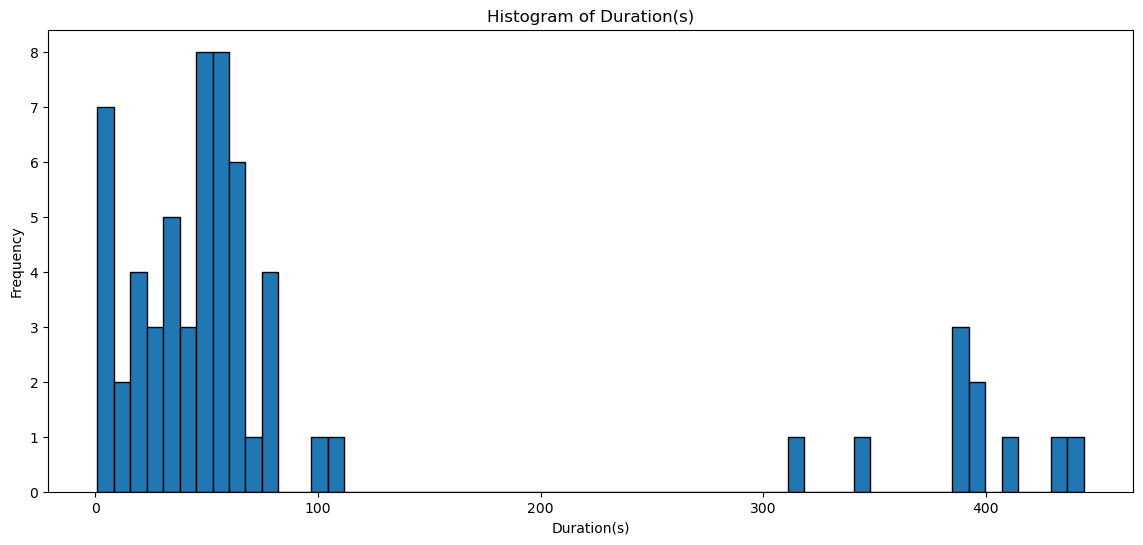

In [5]:
plt.figure(figsize=(14, 6))
plt.hist(anormal_flight_time_info['Duration(s)'], bins=60, edgecolor='black')
plt.title('Histogram of Duration(s)')
plt.xlabel('Duration(s)')
plt.ylabel('Frequency')
plt.show()

In [6]:
anormal_df_f = pd.read_csv('anormal_flights.csv')
anormal_df_f = anormal_df_f.drop(['onground','alert','spi','squawk','lastposupdate','lastcontact','hour'], axis=1)
anormal_df_f

,time,lat,lon,velocity,heading,vertrate,baroaltitude,geoaltitude,flight,icao24,callsign
0,1579717239,33.832072,-84.381180,130.766970,241.317583,0.00000,1409.70,1447.80,1,a03448,N112GS
1,1579717240,33.831528,-84.382287,130.766970,241.317583,0.00000,1409.70,1447.80,1,a03448,N112GS
2,1579717241,33.831207,-84.383016,130.766970,241.317583,0.00000,1409.70,1447.80,1,a03448,N112GS
3,1579717242,33.830582,-84.384384,130.766970,241.317583,0.00000,1409.70,1447.80,1,a03448,N112GS
4,1579717243,33.829971,-84.385762,130.766970,241.317583,0.00000,1409.70,1447.80,1,a03448,N112GS
...,...,...,...,...,...,...,...,...,...,...,...
1831,1560961009,33.752467,-84.459229,160.230932,112.860424,-10.72896,3299.46,3421.38,0,ad767d,DAL1127
1832,1560961010,33.751968,-84.457902,160.364663,113.439936,-11.37920,3291.84,3413.76,0,ad767d,DAL1127
1833,1560961011,33.751373,-84.456332,160.045008,114.093386,-11.05408,3284.22,3406.14,0,ad767d,DAL1127
1834,1560961012,33.750652,-84.454536,159.999528,114.504940,-11.05408,3268.98,3390.90,0,ad767d,DAL1127


In [7]:
pair_count_an = anormal_df_f.groupby(['icao24','callsign','flight']).size().reset_index(name='count')
pair_count_an = pair_count_an.sort_values(by='count', ascending=False)
pair_count_an

,icao24,callsign,flight,count
8,a9ecde,N739E,0,435
6,a6ff6c,N550AA,6,397
3,a42329,OPT366,11,345
12,ad1c11,AAL1630,0,110
4,a51b1a,UAL2308,0,102
0,a03448,N112GS,1,80
1,a2c087,ASA784,0,67
2,a3b3df,DAL1901,0,64
10,aa7b10,SWA3288,0,53
11,ac0cf8,DAL2979,2,52


In [8]:
import requests
from bs4 import BeautifulSoup

def info_flight_single(callsign):
    base_url = "https://www.flightaware.com/resources/registration/"
    headers = {
        'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/58.0.3029.110 Safari/537.36',
        'Accept': 'text/html,application/xhtml+xml,application/xml;q=0.9,image/webp,*/*;q=0.8',
        'Accept-Language': 'en-US,en;q=0.5',
        'Referer': 'https://www.google.com',
        'Connection': 'keep-alive',
        'Upgrade-Insecure-Requests': '1'
    }

    url = base_url + callsign
    try:
        # Make the HTTP request with headers
        response = requests.get(url, headers=headers)
        # Check the HTTP response status
        if response.status_code == 200:
            # Parse the HTML content
            soup = BeautifulSoup(response.text, 'html.parser')
            # Find the specific section containing the aircraft type
            aircraft_summary = soup.find("div", {"class": "medium-3 columns"})
            # Extract the aircraft type if available
            if aircraft_summary:
                aircraft_type = aircraft_summary.get_text(strip=True)
                return aircraft_type
            else:
                return "Aircraft type not found"
        else:
            return f"Error: HTTP status code {response.status_code}"
    except Exception as e:
        return f"Error: {str(e)}"

pair_count_an['info'] = pair_count_an['callsign'].apply(info_flight_single)
pair_count_an

,icao24,callsign,flight,count,info
8,a9ecde,N739E,0,435,2014 BOMBARDIER INC BD-100-1A10Fixed wing mult...
6,a6ff6c,N550AA,6,397,2003 GULFSTREAM AEROSPACE GV-SP (G550)Fixed wi...
3,a42329,OPT366,11,345,Aircraft type not found
12,ad1c11,AAL1630,0,110,Aircraft type not found
4,a51b1a,UAL2308,0,102,Aircraft type not found
0,a03448,N112GS,1,80,2002 CESSNA 525AFixed wing multi engine(8 seat...
1,a2c087,ASA784,0,67,Aircraft type not found
2,a3b3df,DAL1901,0,64,Aircraft type not found
10,aa7b10,SWA3288,0,53,Aircraft type not found
11,ac0cf8,DAL2979,2,52,Aircraft type not found


---
## **Predict Tranjaction For N550AA-squawk_7500**

In [9]:
def extract_flight_id(df):
    data = df.copy()
    data['time_diff'] = data['time'].diff()
    data['flight'] = (data['time_diff'] > 30).cumsum()
    return data

flight_N550AA = anormal_df[(anormal_df['callsign'] == 'N550AA') & (anormal_df['icao24'] == 'a6ff6c')]
flight_N550AA = extract_flight_id(flight_N550AA)
flight_N550AA = flight_N550AA.drop(['time_diff', 'icao24', 'callsign'], axis=1)
flight_N550AA = flight_N550AA.reset_index(drop=True)
flight_N550AA

,time,lat,lon,velocity,heading,vertrate,baroaltitude,geoaltitude,flight
0,1518703240,33.786264,-84.479713,119.418620,80.578256,12.67968,701.04,777.24,0
1,1518703241,33.786438,-84.478361,119.926154,80.618490,13.00480,716.28,792.48,0
2,1518703242,33.786544,-84.477711,120.433747,80.658385,13.00480,731.52,807.72,0
3,1518703243,33.786544,-84.477711,120.941397,80.697945,13.00480,739.14,815.34,0
4,1518703244,33.786916,-84.475136,121.449104,80.737175,12.35456,754.38,822.96,0
...,...,...,...,...,...,...,...,...,...
3048,1571331412,33.795273,-84.421524,58.529169,259.875328,-3.57632,7772.40,678.18,10
3049,1571331413,33.795273,-84.421524,58.529169,259.875328,-3.57632,7772.40,678.18,10
3050,1571331414,33.795273,-84.421524,58.529169,259.875328,-3.57632,7772.40,678.18,10
3051,1571331415,33.795273,-84.421524,58.529169,259.875328,-3.57632,7772.40,678.18,10


In [10]:
from sklearn.preprocessing import MinMaxScaler

train_data = flight_N550AA[flight_N550AA['flight'] != 6].copy()
test_data = flight_N550AA[flight_N550AA['flight'] == 6].copy()

columns_to_scale = ['lat', 'lon', 'velocity', 'heading', 'vertrate', 'baroaltitude', 'geoaltitude']
scaler = MinMaxScaler()

train_data[columns_to_scale] = scaler.fit_transform(train_data[columns_to_scale])
test_data[columns_to_scale] = scaler.transform(test_data[columns_to_scale])

print('Train data after normalization:')
train_data.head()

Train data after normalization:


,time,lat,lon,velocity,heading,vertrate,baroaltitude,geoaltitude,flight
0,1518703240,0.335023,0.000000,0.327406,0.022300,0.766667,0.026144,0.025091,0
1,1518703241,0.336837,0.013714,0.330135,0.022518,0.777778,0.027233,0.026137,0
2,1518703242,0.337938,0.020311,0.332865,0.022733,0.777778,0.028322,0.027182,0
3,1518703243,0.337938,0.020311,0.335594,0.022947,0.777778,0.028867,0.027705,0
4,1518703244,0.341825,0.046425,0.338324,0.023159,0.755556,0.029956,0.028228,0


In [11]:
print('Test data after normalization:')
test_data.head()

Test data after normalization:


,time,lat,lon,velocity,heading,vertrate,baroaltitude,geoaltitude,flight
1328,1531862223,0.924988,0.055781,0.152903,0.414925,0.277778,0.039760,0.034501,6
1329,1531862224,0.924988,0.055781,0.152903,0.414925,0.277778,0.039760,0.034501,6
1330,1531862225,0.911278,0.063834,0.143005,0.415744,0.300000,0.039216,0.033978,6
1331,1531862226,0.904921,0.067718,0.140533,0.414903,0.311111,0.039216,0.033978,6
1332,1531862227,0.890588,0.075677,0.136820,0.415744,0.322222,0.039760,0.034501,6


In [12]:
def prepare_data(data, n_steps):
    X, y = [], []
    for i in range(len(data) - n_steps):
        X.append(data.iloc[i:i+n_steps][['lat', 'lon', 'velocity', 'heading', 'vertrate','baroaltitude','geoaltitude']].values)
        y.append(data.iloc[i+n_steps][['lat', 'lon', 'geoaltitude']].values)
    return np.array(X), np.array(y)

n_steps = 10

X_train, y_train = prepare_data(train_data, n_steps)
X_test, y_test = prepare_data(test_data, n_steps)

X_train = X_train.reshape((X_train.shape[0], n_steps, X_train.shape[2]))
X_test = X_test.reshape((X_test.shape[0], n_steps, X_test.shape[2]))

print('Shape of X_train_lstm:', X_train.shape)
print('Shape of y_train_lstm:', y_train.shape)
print('Shape of X_test_lstm:', X_test.shape)
print('Shape of y_test_lstm:', y_test.shape)

Shape of X_train_lstm: (2646, 10, 7)
Shape of y_train_lstm: (2646, 3)
Shape of X_test_lstm: (387, 10, 7)
Shape of y_test_lstm: (387, 3)


---
### **LSTM Model**

In [13]:
from keras.models import Sequential
from keras.layers import LSTM, Dense

In [14]:
model_lstm = Sequential()
model_lstm.add(LSTM(50, activation='relu', input_shape=(n_steps, X_train.shape[2])))
model_lstm.add(Dense(3)) # 3 output features: latitude, longitude, and geoaltitude
model_lstm.compile(optimizer='adam', loss='mse')

model_lstm.fit(X_train, y_train, epochs=50, verbose=1)

mse_lstm = model_lstm.evaluate(X_test, y_test, verbose=0)
print(f'Mean Squared Error on Test Set (lat, lon, geoaltitude) using LSTM: {mse_lstm}')

Metal device set to: Apple M1 Pro

systemMemory: 16.00 GB
maxCacheSize: 5.33 GB



2024-07-08 11:09:55.155061: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2024-07-08 11:09:55.155547: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Epoch 1/50


2024-07-08 11:09:55.402112: W tensorflow/core/platform/profile_utils/cpu_utils.cc:128] Failed to get CPU frequency: 0 Hz
2024-07-08 11:09:55.750280: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:113] Plugin optimizer for device_type GPU is enabled.


83/83 [==============================] - 10s 108ms/step - loss: 0.0346
Epoch 2/50
83/83 [==============================] - 9s 103ms/step - loss: 0.0040
Epoch 3/50
83/83 [==============================] - 9s 104ms/step - loss: 0.0027
Epoch 4/50
83/83 [==============================] - 9s 105ms/step - loss: 0.0023
Epoch 5/50
83/83 [==============================] - 8s 98ms/step - loss: 0.0021
Epoch 6/50
83/83 [==============================] - 8s 99ms/step - loss: 0.0019
Epoch 7/50
83/83 [==============================] - 8s 97ms/step - loss: 0.0017
Epoch 8/50
83/83 [==============================] - 8s 95ms/step - loss: 0.0015
Epoch 9/50
83/83 [==============================] - 8s 94ms/step - loss: 0.0014
Epoch 10/50
83/83 [==============================] - 8s 100ms/step - loss: 0.0013
Epoch 11/50
83/83 [==============================] - 8s 94ms/step - loss: 0.0012
Epoch 12/50
83/83 [==============================] - 8s 95ms/step - loss: 0.0011
Epoch 13/50
83/83 [=======================

2024-07-08 11:16:42.237845: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:113] Plugin optimizer for device_type GPU is enabled.


Mean Squared Error on Test Set (lat, lon, geoaltitude) using LSTM: 0.0001528932189103216


In [15]:
y_pred_lstm = model_lstm.predict(X_test)
y_pred_lat_lstm = y_pred_lstm[:, 0]
y_pred_lon_lstm = y_pred_lstm[:, 1]
y_pred_geoaltitude_lstm = y_pred_lstm[:, 2]

 6/13 [============>.................] - ETA: 0s

2024-07-08 11:16:43.124629: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:113] Plugin optimizer for device_type GPU is enabled.


13/13 [==============================] - 0s 17ms/step


---
### **GRU Model**

In [16]:
from keras.layers import GRU

In [17]:
# Create and train GRU model
model_gru = Sequential()
model_gru.add(GRU(50, activation='relu', input_shape=(n_steps, X_train.shape[2])))
model_gru.add(Dense(3))  # Output layer for latitude, longitude, geoaltitude
model_gru.compile(optimizer='adam', loss='mse')

model_gru.fit(X_train, y_train, epochs=50, verbose=1)

# Evaluate GRU model
mse_gru = model_gru.evaluate(X_test, y_test, verbose=0)
print(f'Mean Squared Error on Test Set (lat, lon, geoaltitude) using GRU: {mse_gru}')

Epoch 1/50


2024-07-08 11:16:43.877404: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:113] Plugin optimizer for device_type GPU is enabled.


83/83 [==============================] - 12s 135ms/step - loss: 0.0321
Epoch 2/50
83/83 [==============================] - 10s 125ms/step - loss: 0.0034
Epoch 3/50
83/83 [==============================] - 11s 133ms/step - loss: 0.0024
Epoch 4/50
83/83 [==============================] - 11s 128ms/step - loss: 0.0018
Epoch 5/50
83/83 [==============================] - 10s 123ms/step - loss: 0.0013
Epoch 6/50
83/83 [==============================] - 10s 116ms/step - loss: 0.0011
Epoch 7/50
83/83 [==============================] - 9s 113ms/step - loss: 0.0011
Epoch 8/50
83/83 [==============================] - 10s 115ms/step - loss: 9.7143e-04
Epoch 9/50
83/83 [==============================] - 9s 114ms/step - loss: 9.6365e-04
Epoch 10/50
83/83 [==============================] - 10s 115ms/step - loss: 9.1582e-04
Epoch 11/50
83/83 [==============================] - 9s 112ms/step - loss: 9.0106e-04
Epoch 12/50
83/83 [==============================] - 10s 126ms/step - loss: 8.4140e-04
Epoch 1

2024-07-08 11:24:47.126310: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:113] Plugin optimizer for device_type GPU is enabled.


Mean Squared Error on Test Set (lat, lon, geoaltitude) using GRU: 0.0001560369273647666


In [18]:
# Predict with GRU model
y_pred_gru = model_gru.predict(X_test)
y_pred_lat_gru = y_pred_gru[:, 0]
y_pred_lon_gru = y_pred_gru[:, 1]
y_pred_geoaltitude_gru = y_pred_gru[:, 2]

 5/13 [==========>...................] - ETA: 0s

2024-07-08 11:24:47.664664: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:113] Plugin optimizer for device_type GPU is enabled.


13/13 [==============================] - 0s 20ms/step


---
### SimpleRNN Model

In [19]:
from keras.layers import SimpleRNN, Dense

In [20]:

model_rnn = Sequential()
model_rnn.add(SimpleRNN(50, activation='relu', input_shape=(n_steps, X_train.shape[2])))
model_rnn.add(Dense(3))
model_rnn.compile(optimizer='adam', loss='mse')
model_rnn.fit(X_train, y_train, epochs=50, verbose=1)
y_pred_rnn = model_rnn.predict(X_test)
y_pred_lat_rnn = y_pred_rnn[:, 0]
y_pred_lon_rnn = y_pred_rnn[:, 1]
y_pred_geoaltitude_rnn = y_pred_rnn[:, 2]

Epoch 1/50


2024-07-08 11:24:48.330728: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:113] Plugin optimizer for device_type GPU is enabled.


83/83 [==============================] - 4s 39ms/step - loss: 0.0608
Epoch 2/50
83/83 [==============================] - 3s 37ms/step - loss: 0.0037
Epoch 3/50
83/83 [==============================] - 3s 37ms/step - loss: 0.0023
Epoch 4/50
83/83 [==============================] - 3s 38ms/step - loss: 0.0017
Epoch 5/50
83/83 [==============================] - 3s 38ms/step - loss: 0.0014
Epoch 6/50
83/83 [==============================] - 3s 38ms/step - loss: 0.0013
Epoch 7/50
83/83 [==============================] - 3s 38ms/step - loss: 0.0012
Epoch 8/50
83/83 [==============================] - 3s 38ms/step - loss: 0.0011
Epoch 9/50
83/83 [==============================] - 3s 38ms/step - loss: 0.0011
Epoch 10/50
83/83 [==============================] - 3s 38ms/step - loss: 0.0010
Epoch 11/50
83/83 [==============================] - 3s 38ms/step - loss: 9.8594e-04
Epoch 12/50
83/83 [==============================] - 3s 38ms/step - loss: 9.3054e-04
Epoch 13/50
83/83 [=====================

2024-07-08 11:27:29.721331: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:113] Plugin optimizer for device_type GPU is enabled.


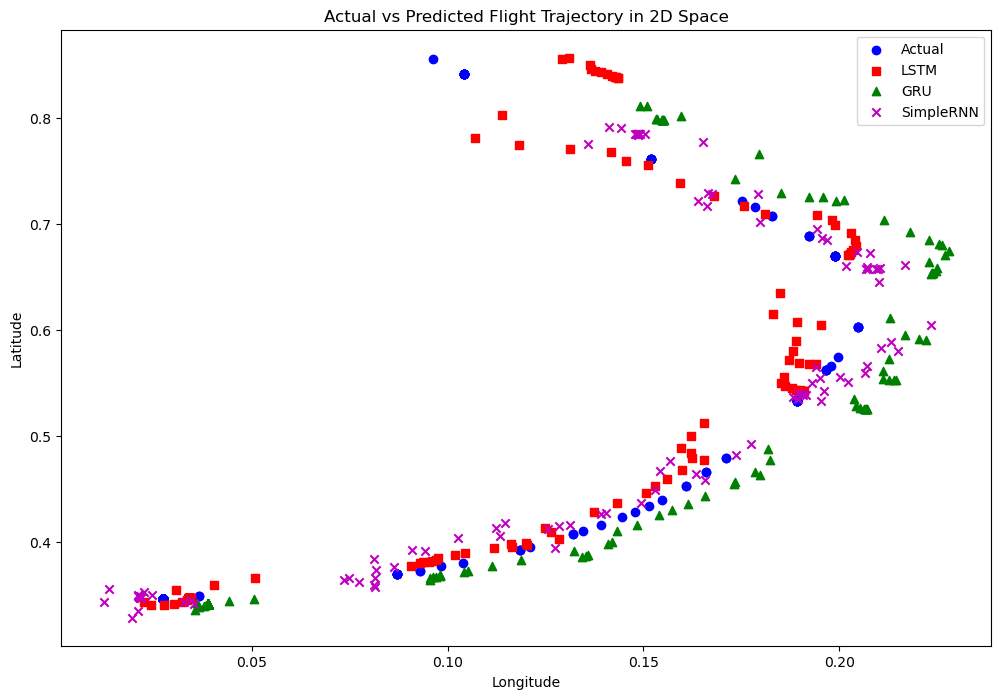

In [21]:
plt.figure(figsize=(12, 8))
plt.scatter(test_data['lon'].values[n_steps:], test_data['lat'].values[n_steps:], c='b', marker='o', label='Actual')
plt.scatter(y_pred_lon_lstm, y_pred_lat_lstm, c='r', marker='s', label='LSTM')
plt.scatter(y_pred_lon_gru, y_pred_lat_gru, c='g', marker='^', label='GRU')
plt.scatter(y_pred_lon_rnn, y_pred_lat_rnn, c='m', marker='x', label='SimpleRNN')

plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend()
plt.title('Actual vs Predicted Flight Trajectory in 2D Space')
plt.show()


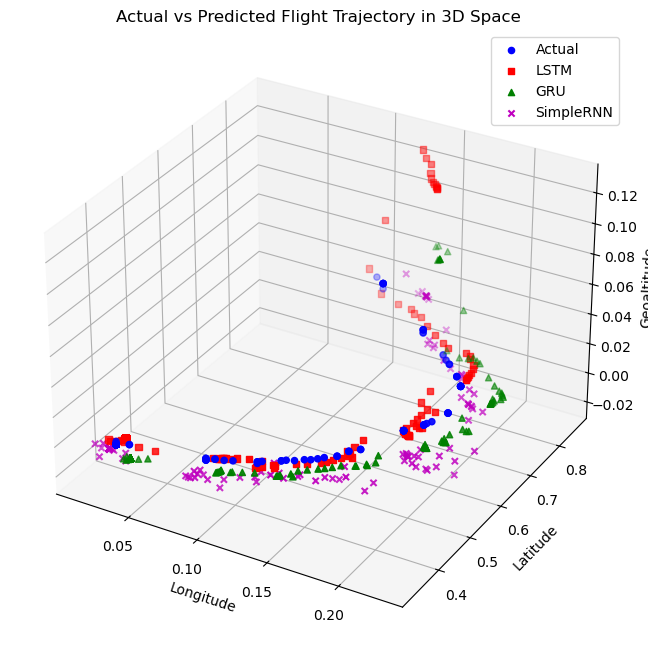

In [22]:
fig = plt.figure(figsize=(16, 8))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(test_data['lon'].values[n_steps:], test_data['lat'].values[n_steps:], test_data['geoaltitude'].values[n_steps:], c='b', marker='o', label='Actual')
ax.scatter(y_pred_lon_lstm, y_pred_lat_lstm, y_pred_geoaltitude_lstm, c='r', marker='s', label='LSTM')
ax.scatter(y_pred_lon_gru, y_pred_lat_gru, y_pred_geoaltitude_gru, c='g', marker='^', label='GRU')
ax.scatter(y_pred_lon_rnn, y_pred_lat_rnn, y_pred_geoaltitude_rnn, c='m', marker='x', label='SimpleRNN')

ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_zlabel('Geoaltitude')

plt.legend()
plt.title('Actual vs Predicted Flight Trajectory in 3D Space')
plt.show()


In [23]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Calculate errors for LSTM
error_lat_lstm = y_test[:, 0] - y_pred_lat_lstm
error_lon_lstm = y_test[:, 1] - y_pred_lon_lstm
error_geoaltitude_lstm = y_test[:, 2] - y_pred_geoaltitude_lstm
euclidean_distance_lstm = np.sqrt(error_lat_lstm**2 + error_lon_lstm**2 + error_geoaltitude_lstm**2)

error_df_lstm = pd.DataFrame({
    'Error Latitude': error_lat_lstm,
    'Error Longitude': error_lon_lstm,
    'Error Altitude': error_geoaltitude_lstm,
    'Euclidean Distance': euclidean_distance_lstm
})

# Calculate errors for GRU
error_lat_gru = y_test[:, 0] - y_pred_lat_gru
error_lon_gru = y_test[:, 1] - y_pred_lon_gru
error_geoaltitude_gru = y_test[:, 2] - y_pred_geoaltitude_gru
euclidean_distance_gru = np.sqrt(error_lat_gru**2 + error_lon_gru**2 + error_geoaltitude_gru**2)

error_df_gru = pd.DataFrame({
    'Error Latitude': error_lat_gru,
    'Error Longitude': error_lon_gru,
    'Error Altitude': error_geoaltitude_gru,
    'Euclidean Distance': euclidean_distance_gru
})

# Calculate errors for RNN
error_lat_rnn = y_test[:, 0] - y_pred_lat_rnn
error_lon_rnn = y_test[:, 1] - y_pred_lon_rnn
error_geoaltitude_rnn = y_test[:, 2] - y_pred_geoaltitude_rnn
euclidean_distance_rnn = np.sqrt(error_lat_rnn**2 + error_lon_rnn**2 + error_geoaltitude_rnn**2)

error_df_rnn = pd.DataFrame({
    'Error Latitude': error_lat_rnn,
    'Error Longitude': error_lon_rnn,
    'Error Altitude': error_geoaltitude_rnn,
    'Euclidean Distance': euclidean_distance_rnn
})

In [24]:
fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=('Error Latitude', 'Error Longitude', 'Error Altitude', 'Euclidean Distance')
)

# Add traces for GRU errors
fig.add_trace(go.Scatter(y=error_df_gru['Error Latitude'], mode='lines', name='GRU Error Latitude'), row=1, col=1)
fig.add_trace(go.Scatter(y=error_df_gru['Error Longitude'], mode='lines', name='GRU Error Longitude'), row=1, col=2)
fig.add_trace(go.Scatter(y=error_df_gru['Error Altitude'], mode='lines', name='GRU Error Altitude'), row=2, col=1)
fig.add_trace(go.Scatter(y=error_df_gru['Euclidean Distance'], mode='lines', name='GRU Euclidean Distance'), row=2, col=2)

# Add traces for LSTM errors
fig.add_trace(go.Scatter(y=error_df_lstm['Error Latitude'], mode='lines', name='LSTM Error Latitude'), row=1, col=1)
fig.add_trace(go.Scatter(y=error_df_lstm['Error Longitude'], mode='lines', name='LSTM Error Longitude'), row=1, col=2)
fig.add_trace(go.Scatter(y=error_df_lstm['Error Altitude'], mode='lines', name='LSTM Error Altitude'), row=2, col=1)
fig.add_trace(go.Scatter(y=error_df_lstm['Euclidean Distance'], mode='lines', name='LSTM Euclidean Distance'), row=2, col=2)

# Add traces for RNN errors
fig.add_trace(go.Scatter(y=error_df_rnn['Error Latitude'], mode='lines', name='RNN Error Latitude'), row=1, col=1)
fig.add_trace(go.Scatter(y=error_df_rnn['Error Longitude'], mode='lines', name='RNN Error Longitude'), row=1, col=2)
fig.add_trace(go.Scatter(y=error_df_rnn['Error Altitude'], mode='lines', name='RNN Error Altitude'), row=2, col=1)
fig.add_trace(go.Scatter(y=error_df_rnn['Euclidean Distance'], mode='lines', name='RNN Euclidean Distance'), row=2, col=2)

fig.update_layout(
    height=800, 
    width=1600, 
    title_text="Error Analysis (LSTM vs GRU vs RNN)",
    annotations=[
        dict(
            x=0.225, y=1.05,
            xref='paper', yref='paper',
            text='Error Latitude',
            showarrow=False,
            font=dict(size=14)
        ),
        dict(
            x=0.775, y=1.05,
            xref='paper', yref='paper',
            text='Error Longitude',
            showarrow=False,
            font=dict(size=14)
        ),
        dict(
            x=0.225, y=0.475,
            xref='paper', yref='paper',
            text='Error Altitude',
            showarrow=False,
            font=dict(size=14)
        ),
        dict(
            x=0.775, y=0.475,
            xref='paper', yref='paper',
            text='Euclidean Distance',
            showarrow=False,
            font=dict(size=14)
        )
    ]
)
fig.show()

In [25]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Define a function to calculate Mean Absolute Error (MAE), Mean Relative Error (MRE), and Root Mean Squared Error (RMSE)
def calculate_errors(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred, multioutput='raw_values')
    mre = np.mean(np.abs((y_true - y_pred) / y_true), axis=0)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred, multioutput='raw_values'))
    return mae, mre, rmse

def create_error_table(y_test, y_pred_lstm, y_pred_gru, y_pred_rnn):
    mae_lstm, mre_lstm, rmse_lstm = calculate_errors(y_test, y_pred_lstm)
    mae_gru, mre_gru, rmse_gru = calculate_errors(y_test, y_pred_gru)
    mae_rnn, mre_rnn, rmse_rnn = calculate_errors(y_test, y_pred_rnn)
    
    error_table = pd.DataFrame({
        'Model': ['LSTM', 'GRU', 'RNN'],
        'MAE Latitude ': [mae_lstm[0], mae_gru[0], mae_rnn[0]],
        'MAE Longitude ': [mae_lstm[1], mae_gru[1], mae_rnn[1]],
        'MAE Altitude ': [mae_lstm[2], mae_gru[2], mae_rnn[2]],
        'MRE Latitude ': [mre_lstm[0], mre_gru[0], mre_rnn[0]],
        'MRE Longitude ': [mre_lstm[1], mre_gru[1], mre_rnn[1]],
        'MRE Altitude ': [mre_lstm[2], mre_gru[2], mre_rnn[2]],
        'RMSE Latitude ': [rmse_lstm[0], rmse_gru[0], rmse_rnn[0]],
        'RMSE Longitude ': [rmse_lstm[1], rmse_gru[1], rmse_rnn[1]],
        'RMSE Altitude ': [rmse_lstm[2], rmse_gru[2], rmse_rnn[2]]
    })
    return error_table

error_table = create_error_table(y_test, y_pred_lstm, y_pred_gru, y_pred_rnn)
error_table


,Model,MAE Latitude,MAE Longitude,MAE Altitude,MRE Latitude,MRE Longitude,MRE Altitude,RMSE Latitude,RMSE Longitude,RMSE Altitude
0,LSTM,0.004739,0.008229,0.008551,0.010415,0.220668,inf,0.009953,0.010619,0.015711
1,GRU,0.006922,0.014510,0.005829,0.015583,0.377456,inf,0.010658,0.016872,0.008357
2,RNN,0.005770,0.007447,0.006482,0.011104,0.193775,inf,0.012962,0.010461,0.008228
